# Retrospective BO v7 — ANN Committee SHAP

SHAP feature importance for the 6-member Caruana ANN committee (`models/BO/committee_v7pub`), computed over the 30 experimental points with a composition-renormalizing KernelExplainer. torch is pinned to 1 thread so the feature order reproduces exactly.

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from matsci_ml.config import FEATURE_COLS
from matsci_ml import PyTorchANNTrainer, set_all_seeds

fm.fontManager.addfont('/usr/share/fonts/truetype/msttcorefonts/Arial.ttf')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'

RANDOM_SEED = 42
NORM_TO_MG = 31.0
set_all_seeds(RANDOM_SEED)
os.makedirs('plots/bo', exist_ok=True)

df = pd.read_csv('data/mustard_fresh_weight.csv')


In [2]:
import shap
import torch
torch.set_num_threads(1)

COMM_DIR = 'models/BO/committee_v7pub'
comm_res = json.load(open('models/BO/committee_v7pub/build_ann_committee_ensemble_v7_pub_result.json'))
comm_meta = json.load(open(f'{COMM_DIR}/committee.json'))
COMM_SEED = comm_res['best_seed']
print(f"Committee: {len(comm_meta['members'])} members, tag={comm_res['selection_tag']}, seed={COMM_SEED}")

scaler_X_c = joblib.load(f'{COMM_DIR}/scaler_X.pkl')
scaler_y_c = joblib.load(f'{COMM_DIR}/scaler_y.pkl')
comm_trainers, comm_weights = [], []
for m in comm_meta['members']:
    comm_trainers.append(PyTorchANNTrainer().load(f"{COMM_DIR}/{m['file']}"))
    comm_weights.append(m['weight'])
    print(f"  {m['library_key']:>10}  w={m['weight']:.3f}  layers={m['params']['n_layers']}")


def comm_predict_scaled(A):
    """Weighted ensemble prediction in scaled-y space (A is scaled features)."""
    out = np.zeros(len(A), dtype=np.float64)
    for w, tr in zip(comm_weights, comm_trainers):
        out += w * tr.predict(A)
    return out


def comm_predict_mg(X_raw):
    pred_s = comm_predict_scaled(scaler_X_c.transform(X_raw))
    return scaler_y_c.inverse_transform(pred_s.reshape(-1, 1)).ravel() * NORM_TO_MG



Committee: 6 members, tag=ORDER_SATISFIED, seed=16
     ann_136  w=0.556  layers=3
      ann_46  w=0.111  layers=4
     ann_110  w=0.167  layers=5
      ann_31  w=0.056  layers=2
      ann_85  w=0.056  layers=5
      ann_48  w=0.056  layers=5


  0%|          | 0/30 [00:00<?, ?it/s]

 27%|██▋       | 8/30 [00:00<00:00, 76.92it/s]

 53%|█████▎    | 16/30 [00:00<00:00, 78.26it/s]

 80%|████████  | 24/30 [00:00<00:00, 78.93it/s]

100%|██████████| 30/30 [00:00<00:00, 78.76it/s]

Mean |SHAP| per feature (6-member committee), mg/cm^2:
  GUM: 1.301
  ALG: 2.054
  PVA: 1.525
  CMC: 1.612
  MassLoading: 1.347
SHAP order: ALG > CMC > PVA > MassLoading > GUM
  PVA #3, GUM #5  (target: PVA in 3/4, GUM last -> True)


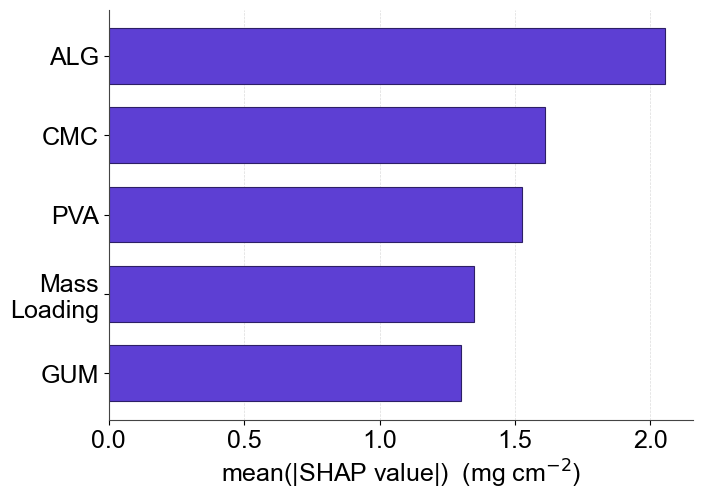

In [3]:
# SHAP importance bar plot — 6-member ANN committee (Caruana ensemble)
# Computed on the WEIGHTED 6-member committee
import shap
import torch
torch.set_num_threads(1)

PLOT_NAMES = ['GUM', 'ALG', 'PVA', 'CMC', 'Mass\nLoading']

X_all = df[FEATURE_COLS].values
X_sc = scaler_X_c.transform(X_all)


def predict_fn(X_scaled):
    X_orig = scaler_X_c.inverse_transform(X_scaled)
    comp = X_orig[:, :4]
    comp_sum = comp.sum(axis=1, keepdims=True)
    comp_sum = np.where(comp_sum == 0, 1.0, comp_sum)
    X_orig[:, :4] = comp / comp_sum
    preds_sc = comm_predict_scaled(scaler_X_c.transform(X_orig))
    return scaler_y_c.inverse_transform(preds_sc.reshape(-1, 1)).ravel() * NORM_TO_MG


np.random.seed(RANDOM_SEED)
explainer = shap.KernelExplainer(predict_fn, X_sc)
shap_values = explainer.shap_values(X_sc, nsamples=500)

print('Mean |SHAP| per feature (6-member committee), mg/cm^2:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col}: {np.abs(shap_values[:, i]).mean():.3f}')

mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)
labels_sorted = [PLOT_NAMES[i] for i in order]
values_sorted = mean_abs[order]

_desc = np.argsort(mean_abs)[::-1]
_rk = {c: int(np.where(_desc == i)[0][0]) + 1 for i, c in enumerate(FEATURE_COLS)}
print(f"SHAP order: {' > '.join(FEATURE_COLS[i] for i in _desc)}")
print(f"  PVA #{_rk['PVA']}, GUM #{_rk['GUM']}  "
      f"(target: PVA in 3/4, GUM last -> "
      f"{_rk['PVA'] in (3, 4) and _rk['GUM'] == 5})")

IRIS = '#5D3FD3'
EDGE = '#2D1F66'

MARGINS = dict(left=0.22, right=0.95, top=0.95, bottom=0.13)

fig, ax = plt.subplots(figsize=(8, 5))
fig.subplots_adjust(**MARGINS)

ax.barh(np.arange(len(values_sorted)), values_sorted,
        color=IRIS, edgecolor=EDGE, linewidth=0.8, height=0.7)

ax.set_yticks(np.arange(len(values_sorted)))
ax.set_yticklabels(labels_sorted, fontsize=18)
ax.set_xlabel(r'mean(|SHAP value|)  (mg cm$^{-2}$)', fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#444444')
ax.spines['bottom'].set_color('#444444')
ax.xaxis.grid(True, linestyle='--', linewidth=0.5, color='#CCCCCC', alpha=0.7)
ax.set_axisbelow(True)

xmax = values_sorted.max()
ax.set_xlim(0, xmax * 1.05)
ax.set_xticks([0.0, 0.5, 1.0, 1.5, 2.0])

fig.savefig('plots/bo/bo_ann_aug_30pts_shap_bar_v7pub.svg', format='svg')
plt.show()